In [138]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# <div align="center">**Automatic for the People and Derivatives in Your Pocket**
 </div>

### <div align="center">MOD300 Mandatory project 1 </div>

<div align="center">Written by Jone Bakken & Petter Worpvik Tverdal</div>

&nbsp;

<div align="center">6. September 2026</div>

&nbsp;

### Abstract

This project explores floating-point arithmetic, vectorized NumPy operations, and numerical integration/differentiation in Python. Using Python's `sys` library, we saw how floating-point numbers are stored. We found a machine epsilon of $\approx 2.22 \times 10^{-16}$, a maximum of $\approx 1.79 \times 10^{308}$ and a minimum value of  $\approx 2.22 \times 10^{-308}$. We then compared standard Python loops with NumPy arrays, show how vectorized functions and boolean masking make code faster.

To test numerical differentiation, we implemented forward- and central finite-difference functions on a damped oscillation function. Plotting the error across different step sizes $h$ showed that choosing a step size that is too large causes errors because the computer cuts corners from the true, continuous equation. It reached a minimum error of $1.07 \times 10^{-11}$ at step-size $h \approx 2.21 \times 10^{-6}$, compared to the forward difference method which reached a minimum error of $6.39 \times 10^{-9}$ at $h \approx 8.30 \times 10^{-9}$.

Furthermore, we implemented automatic differentiation using dual numbers, which enabled exact derivative evaluations of the damped oscillation without incurring truncation or round-off errors.

Finally, we processed real gyroscope data recorded with the phyphox mobile app. Integrating the angular velocity $\omega_{y}(t)$ gave us the rotation angle $\theta(t)$, and differentiating that angle gave us the original velocity signal back.


### Introduction

When we do mathematical calculations on a computer, numbers are stored using finite memory. Due to this, it cannot store real numbers with infinite decimals, which leads to small rounding errors. Such small errors can accumulate when re-used, so it is important to understand these precision limits in scientific computing. It is also essential to understand efficient coding practices, due to standard Python loops being much slower on large datasets compared to vectorized C-compiled libraries like NumPy.

## 1. Finite-precision arithmetic

### 1.1 How the computer handles decimals

In Python, we can use the `sys` library to get info on how our computer handles floating-point numbers. Running the following code shows size boundaries, machine precision, and power limits:

In [139]:
import sys
float_info = sys.float_info

print(float_info.epsilon, float_info.max, float_info.min)

2.220446049250313e-16 1.7976931348623157e+308 2.2250738585072014e-308


#### Epsilon


The `epsilon` attribute of the `float_info` object represents the computer's rounding error limit. Since computers have finite memory, they cannot represent every one of the infinite decimals between 1 and 2. Instead, it jumps from one number to the next in tiny steps. Epsilon measures the smallest step size between 1.0 and the next representable float.

Usually, the epsilon value is `2.220446049250313e-16`, which equals $2^{-52}$. Python allocates 64 bits to store floating-point numbers using the IEEE 754 standard: 1 bit for positive/negative number, 11 bits for the exponent, and 52 bits for the precision. Storing the fraction across 52 bits gives a minimum step size of $2^{-52}$.

#### Max

The `max` attribute is the biggest number the computer can write down before it runs out of space. If any calculation results in a number bigger than this maximum, the computer gives up and says that the number is infinite.

The exact limit of $\approx 1.79 \times 10^{308} \approx 2^{1024}$ comes from the 11 bits allocated to the exponent in 64-bit numbers:

The 11 exponent bits give $2^{11} = 2048$ possible combinations, where the highest value ($2047$) is reserved for Infinity and NaN. This makes $2046$ the largest usable bit pattern for exponents. Half of these are used to support negative exponents, giving a maximum power of $2^{1023}$.

Multiplying this exponent factor by the full 52 bits of precision (which is nearly 2) gives $2 \times 2^{1023} = 2^{1024}$, which translates to $\approx 1.79 \times 10^{308}$.

#### Min

The `min` attribute is the smallest positive number $> 0$ the computer can represent accurately. It represents the smallest normalized floating-point value in the IEEE 754 standard.

The exact limit of $\approx 2.22 \times 10^{-308} \approx 2^{-1022}$ uses a negative exponent instead of positive. Since the exponent is now $-1022$ (instead of $+1023$ for `max`), we get a very small number. Making this into a base 10 number:

$2^{-1022} = 10^{-1022 \times 0.301} \approx 10^{-308}$, giving approximately $2.22 \times 10^{-308}$.

If a number becomes smaller than `min`, the computer cannot represent it with full precision, and it will be rounded down to zero.


### 1.2 Precision errors in Python

With the limitations on number representation in computers, they cannot always represent all decimal numbers exactly. This leads to some very obvious rounding errors:


In [140]:
result = 0.1 + 0.2
print(result)
print(result == 0.3)

0.30000000000000004
False


Python gives us $0.30000000000000004$, and therefore it returns "False". This is because of how computers store decimal numbers:

The numbers $0.1$, $0.2$ and $0.3$ cannot be represented directly in binary, and when these wrongly represented numbers are added together, the errors accumulate and get larger than the machine precision (epsilon).

However, numbers like $0.125$ and $0.5$ can be represented exactly in binary, because they are powers of 2 ($\frac{1}{8}$ and $\frac{1}{2}$). Therefore, they can be compared accurately:

In [141]:
result = 0.125 + 0.5
print(result)
print(result == 0.625)

result2 = 0.25 + 0.25 + 0.25
print(result2)
print(result2 == 0.75)

0.625
True
0.75
True


`result2` in the above code snippet also shows that since $0.25 = \frac{1}{4}$ and $0.75 = \frac{3}{4}$, these can all be represented in binary, so the comparison works.

### 1.3 The `==` operator

Since we always want to make programs that are universal, we need to think carefully about how we compare two floating-point numbers. Using the `==` operator is risky because the rounding errors explained will cause false negatives.

For instance, if we use a loop that checks if a certain value is reached, using `==` could make the loop run endlessly. A fix to this issue would be to check if two numbers are close enough for the epsilon to recognize it:

In [142]:
result = 0.0
precision = sys.float_info.epsilon

# This loop will continue as long as the result is NOT close enough to 1
while abs(result - 1.0) > precision:
    result += 0.1

print(result)

0.9999999999999999


By using a comparison based on the precision value, the loop recognizes when we have reached approximately 1.0 and stops.

### 1.4 Conclusion

In this exercise, we explored how the IEEE 754 64-bit floating-point standard determines binary numerical storage in Python. Looking at these machine limits demonstrates why binary rounding prevents exact decimal representations (such as $0.1 + 0.2$).

To prevent infinite loops and false comparisons in numerical computing, it is necessary to go away from exact equality `==` and instead implement a check to see if numbers are approximately the same.

## 2. Get up to speed with NumPy

### 2.1 Executing vectorized functions vs. Python lists

NumPy is a very useful Python library, which creates arrays of floats that are processed in C-compiled memory rather than slow Python loops.

The main advantage NumPy has over regular Python is that it allows you to perform operations on entire arrays at once, without having to loop through each element. This is called **vectorization**, and is way more effective than using Python loops. In this way, we can have **vectorized functions** using NumPy, instead of using a whole Python loop for simple operations.

Below we create a NumPy array `x` with 10 linearly spaced values between 0 and 1, convert it to a Python list x_list, and use the `np.exp` function on the list:

In [143]:
x = np.linspace(0, 1, 10)

x_list = list(x)

np.exp(x_list)
print(x_list)

try:
    np.exp(-x_list)
    print(x_list)
except TypeError as e:
    print(f"\nFailed with TypeError: {e}")


[np.float64(0.0), np.float64(0.1111111111111111), np.float64(0.2222222222222222), np.float64(0.3333333333333333), np.float64(0.4444444444444444), np.float64(0.5555555555555556), np.float64(0.6666666666666666), np.float64(0.7777777777777777), np.float64(0.8888888888888888), np.float64(1.0)]

Failed with TypeError: bad operand type for unary -: 'list'


Here, the second function call fails. This happens due to the order Python does operations in:

The first call (`np.exp(x_list)`) works because NumPy automatically converts the list into an array, before it uses the exponential function on all elements.

The second call (`np.exp(-x_list)`) does not work because Python always checks the inside of a parenthesis before calling the outer function. Python tries to use the minus operator on the list first, and this is not a feature in Python. Therefore, it throws a `TypeError` and crashes before the function gets called.

If we have to call a function on a whole Python list without converting it to a NumPy array, a workaround is possible as follows:

In [144]:
x_list = [0, 0.5, 1.0, 1.5, 2.0]

x_list_new = [math.exp(element) for element in x_list]
x_list_new

[1.0,
 1.6487212707001282,
 2.718281828459045,
 4.4816890703380645,
 7.38905609893065]

Here, we use a for-loop to iterate through every element, because regular Python lists lack support for vectorized operations.

### 2.2 Other ways to create a NumPy array

NumPy provides other functions for creating arrays with predefined values. These are useful when working with numerical data.

The following code snippet demonstrates different ways to create arrays:

In [145]:
a = np.zeros(20)

b = np.ones(20)

c = np.linspace(0, 10, 11)

d = np.linspace(0, 10, 11, endpoint=False)

vector = np.arange(5) + 1
e = 2*vector

print(a)
print(b)
print(c)
print(d)
print(e)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
[0.         0.90909091 1.81818182 2.72727273 3.63636364 4.54545455
 5.45454545 6.36363636 7.27272727 8.18181818 9.09090909]
[ 2  4  6  8 10]


`np.zeros(20)` creates a NumPy array with 20 elements, where they all get initialized to 0.0.

`np.ones(20)` creates a NumPy array with 20 elements, where they all get initialized to 1.0.

`np.linspace(0, 10, 11)` makes an array of 11 evenly spaced values between 0 and including 10.

`np.linspace(0, 10, 11, endpoint=False)` generates 11 evenly spaced values between 0 and 10, but using `endpoint=False`, it excludes 10.

`vector = np.arange(5) + 1` creates an array with numbers from 1 to 5, and `2*vector` multiplies every element in the array by 2, to finally get the array `[2, 4, 6, 8, 10]`.

Now, if we want to do all these computations on native Python lists, it clearly gets more complicated:

A key advantage of NumPy is that operations apply to every element without explicit loops:



In [146]:
# Same as np.zeros(20)
a_list = [0.0] * 20

# Same as np.ones(20)
b_list = [1.0] * 20

# Same as np.linspace(0, 10, 11)
start, stop, num = 0, 10, 11
step = (stop - start) / (num - 1)

c_list = [start + i * step for i in range(num)]

# Same as np.linspace(0, 10, 11, endpoint=False)
step_no_end = (stop - start) / num

d_list = [round(start + i * step_no_end, 2) for i in range(num)]

# Same as vector = np.arange(5) + 1 and 2*vector
e_list = [2 * (i + 1) for i in range(5)]

print(a_list)
print(b_list)
print(c_list)
print(d_list)
print(e_list)

[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
[0.0, 0.91, 1.82, 2.73, 3.64, 4.55, 5.45, 6.36, 7.27, 8.18, 9.09]
[2, 4, 6, 8, 10]


The list version produces the same numerical results, but it requires more manual work. For example, Python lists do not automatically support multiplying every element by 2. Therefore, we have to use list comprehension, which is more advanced and consuming than a simple NumPy array.

### 2.3 Extracting array subsets using boolean masking

We often want to filter or extract a subset of values from an array based on some conditions, like when only keeping positive numbers or any number above a certain value. NumPy greatly simplifies this by using **boolean masking**, where logical expressions create arrays of `True` and `False` values to choose elements.

Below, we define an array of numbers and check conditions to find any values that are both even and greater than 17:

In [147]:
array_of_numbers = np.array([4, 8, 15, 16, 23, 42, 0, 5])
nnz = np.count_nonzero(array_of_numbers)
print(f'There are {nnz} non-zero numbers in the array.')
is_even = array_of_numbers % 2 == 0
is_greater_than_17 = array_of_numbers > 17
is_even_and_greater_than_17 = is_even & is_greater_than_17


errors = []

try:
    is_even_and_greater_than_17 = is_even and is_greater_than_17
except Exception as e:
    errors.append(e)

try:
    print(array_of_numbers % 2 == 0 & array_of_numbers > 17)
except Exception as e:
    errors.append(e)

print(errors[0])
print(errors[1])


There are 7 non-zero numbers in the array.
The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()
The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()


As seen in the snippet, there was an attempt to combine these conditions using standard Python or without parentheses. This causes errors caught by the try/except blocks:

The first block fails because the Python `and` operator wants NumPy to check if a whole list of answers is True or False. Since this gives multiple answers, it is impossible to return a single True or False answer.

In the same matter, the second block fails because there is no parenthesis. Python sees the `&` operator before any others, so it checks `0 & array_of_numbers` instead of reading from the left. This results in the other statements being cut off and impossible to check.


To provide a fix for this, NumPy has a function called `logical_and()`, which checks the True / False value of two inputs for every element. It returns `True` if both the elements are correct, and `False` otherwise. This makes it possible to compare boolean arrays and filter data with multiple conditions.

Here is how we can fix the previous errors, using NumPy's `np.logical_and()`:


In [148]:

is_even_and_greater_than_17 = np.logical_and(is_even, is_greater_than_17)

np.logical_and(array_of_numbers % 2 == 0, array_of_numbers > 17)

is_even_and_greater_than_17


array([False, False, False, False, False,  True, False, False])

The function `np.logical_and()` allows us to easily combine boolean conditions without having to rewrite code further up. It also keeps the initial boolean masks the same for any other uses later.

### 2.4 Indexing and conditional values using `np.where`

Another useful tool for selecting elements from an array is `np.where`. This function can either return indices where a condition is met, or replace array elements on some condition.

Below, we apply `np.where` in two different use cases:

In [149]:
# This returns indices where the condition is True
indices = np.where(array_of_numbers > 17)[0]
print(indices)

# This replaces elements based on if the condition is True (1) or False (0
binary_array = np.where(array_of_numbers > 17, 1, 0)
print(binary_array)


[4 5]
[0 0 0 0 1 1 0 0]


`np.where(array_of_numbers > 17)[0]`: When np.where is passed only a condition, it returns a tuple containing an array of indices where the condition evaluates to True. The expression `array_of_numbers > 17` is True at indices 4 (23) and 5 (42). The trailing [0] extracts the first element of the tuple, producing the 1D integer array `[4, 5]`.

`np.where(array_of_numbers > 17, 1, 0)`: When provided with three arguments (condition, x, y), the function acts like a vectorized ternary operator. It iterates through `array_of_numbers` and returns 1 for every element greater than 17, and 0 for every element that is not. This produces the array `[0, 0, 0, 0, 1, 1, 0, 0]`.

### 2.5 Conclusion

In this second exercise, we have looked at how NumPy helps with efficient vectorized computations that outperform normal Python loops and list comprehensions. Using array creation functions, boolean masking with `np.logical_and()`, and conditional operations with `np.where()`, allows for fast filtering and element-wise array processing. Writing with NumPy keeps operations vectorized and eliminates complex manual loops.

## 3. Build finite-difference tools

### 3.1 Analytical angular velocity

The damped angle is defined as

$$
\theta(t)=Ae^{-\gamma t}\cos(\omega_0 t)
$$

where:

- $A$ is the amplitude
- $\gamma$ is the damping coefficient
- $\omega_0$ is the angular frequency
- $t$ is time

The analytical angular velocity is

$$
\omega(t)
=
-Ae^{-\gamma t}
\left[
\gamma\cos(\omega_0t)
+
\omega_0\sin(\omega_0t)
\right]
$$


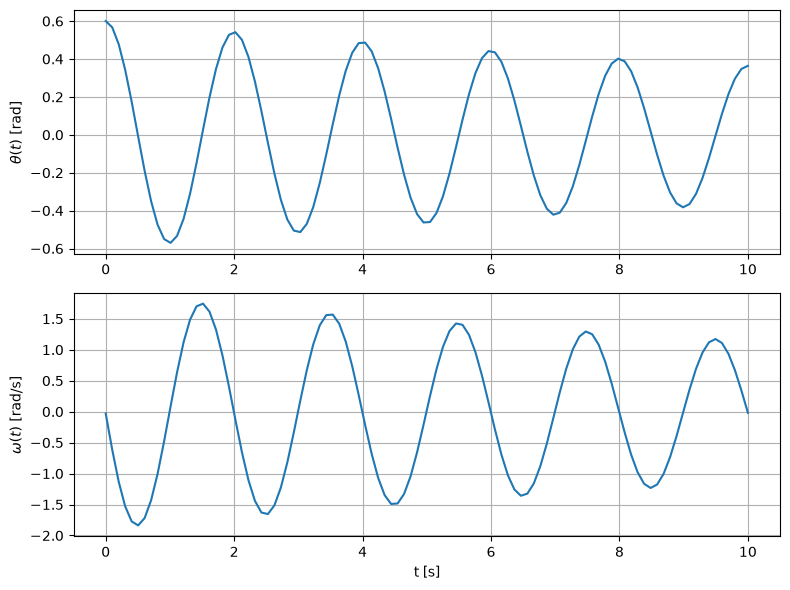

In [150]:
#Code for damped angle and velocity functions with default parameters
def damped_angle(t, A=0.6, gamma=0.05, omega0=np.pi):
  return A*np.exp(-gamma*t)*np.cos(omega0*t)

#Code for damped velocity function with default parameters
def damped_velocity (t, A=0.6, gamma=0.05, omega0=np.pi):
  return -A*np.exp(-gamma*t)*(gamma*np.cos(omega0*t) + omega0*np.sin(omega0*t))


t = np.linspace(0, 10, 100) # Array of time values from 1 to 10 seconds spaced evenly with 100 points

damped = damped_angle(t) # Since we are using a numpy array,
                        # we can pass the entire array to the function
                        # and it will return an array of angles
velocities = damped_velocity(t) 


fig, ax = plt.subplots(2, 1, figsize=(8, 6))

ax[0].plot(t, damped)
ax[0].set_ylabel(r"$\theta(t)$ [rad]")
ax[0].grid()

ax[1].plot(t, velocities)
ax[1].set_xlabel("t [s]")
ax[1].set_ylabel(r"$\omega(t)$ [rad/s]")
ax[1].grid()

plt.tight_layout()
plt.show()


**Figure 1:** Damped angle $\theta(t)$ and angular velocity $\omega(t)$ for
$A=0.6$, $\gamma=0.05\,\mathrm{s^{-1}}$, and $\omega_0=\pi\,\mathrm{rad/s}$.

### 3.2 Forward and central differences
To approximate derivatives numerically, we use finite-difference formulas.

The forward-difference approximation is

$$
D_f y_i =
\frac{y_{i+1}-y_i}{h}
$$

and the central-difference approximation is

$$
D_c y_i =
\frac{y_{i+1}-y_{i-1}}{2h}.
$$

Here, $y_i$ is the current sampled value, $y_{i+1}$ is the next value, $y_{i-1}$ is the previous value, and $h$ is the spacing between the samples.

The functions `forward_diff()` and `central_diff()` are implemented using NumPy slicing instead of Python loops.

The forward-difference function should return an array of length `len(y)-1`, while the central-difference function should return an array of length `len(y)-2`.

To verify that the implementations work correctly, both functions are tested on:

1. A linear function, where the derivative is constant.
2. A quadratic function, where the analytical derivative is known.


In [151]:
def forward_diff(y, h):
  slice = y[1:] - y[:-1]
  return slice / h


def central_diff(y, h):
  slice = y[2:] - y[:-2]
  return slice / (2 * h)

#### Verification

For the linear test function, the numerical derivative should be constant.

For the quadratic test function, the numerical results can be compared with the known analytical derivative to check the accuracy of the two methods.

#### Linear test

For the linear test I chose the function: 
$$
y =
3x + 2
$$

Which got a known constant derivative of 3.

In [152]:
x = np.linspace(0, 10, 11)
h = x[1] - x[0]

y = 3 * x + 2

forward = forward_diff(y, h)
central = central_diff(y, h)

print(forward)
print(central)

[3. 3. 3. 3. 3. 3. 3. 3. 3. 3.]
[3. 3. 3. 3. 3. 3. 3. 3. 3.]


Both `forward_diff()` and `central_diff()` return 3, which shows that the functions work as expected for the linear test.

#### Quadratic test

For the quadric test, I will chose the function
$$
y =
x^2
$$

Which got the derivative
$$
y' =
2x
$$

For the test I chose that x = 2, which gives
$$
y'(2) =
4
$$

I will now use test `forward_diff()` and `central_diff()` with x = 2 and compare them with the analytical derivative.

In [153]:
x = np.linspace(0, 10, 11)
h = x[1] - x[0]

y = x**2

forward = forward_diff(y, h)
central = central_diff(y, h)

print("Forward:")
print("x =", x[:-1])
print("derivative =", forward)

print("\nCentral:")
print("x =", x[1:-1])
print("derivative =", central)

Forward:
x = [0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
derivative = [ 1.  3.  5.  7.  9. 11. 13. 15. 17. 19.]

Central:
x = [1. 2. 3. 4. 5. 6. 7. 8. 9.]
derivative = [ 2.  4.  6.  8. 10. 12. 14. 16. 18.]


For $x=2$, the exact derivative is

$$
f'(2)=2\cdot2=4.
$$

Using the forward difference with $h=1$ gives

$$
\frac{3^2 - 2^2}{1} = 5.
$$

Using the central difference gives

$$
\frac{3^2 - 1^2}{2} = 4.
$$

When we compare the analytical derivative with our code, the numerical derivative, we see that in the linear example both are the same.
However in the quadratic test, the central derivation give us the better result as expected. 



### 3.3 Python function wrapper

In this part I will create a wrapper that can be used with either the `forward_diff` or `central_diff` function. I will then estimate w(0.8) with both functions. Further I will compare both the estimates with the analytical results of the `damped_velocity` function. Last I will demonstarte that the extra arguments in the wrapper works by chosing a non default $A$, $\gamma$ and $\omega_0$.

In the cell below I have created the `derivate_at` function according to the task description.

In [154]:
def derivative_at(f, x, h, method, *args, **kwargs):
    if method == forward_diff:
        points = np.array([x, x + h]) # We need two points for forward difference, so we take x and x + h

    elif method == central_diff:
        points = np.array([x - h, x, x + h]) # We need three points for central difference, so we take x - h, x, and x + h

    else:
        raise ValueError("Method must be forward_diff or central_diff.") #Simple error handling, making sure we are using correct method.

    y = f(points, *args, **kwargs) # Passing the extra arguments to the damped_angle function.

    return method(y, h)[0]

# Forward differentiation at t = 0.8 seconds
forward_diff_approx = derivative_at(damped_angle, 0.8, 0.01, forward_diff)
print(f"Forward differentiation w(0.8): {forward_diff_approx}")

# Central differentiation at t = 0.8 seconds
central_diff_approx = derivative_at(damped_angle, 0.8, 0.01, central_diff)
print(f"Central differentiation w(0.8): {central_diff_approx}")

# Damped velocity at t = 0.8 seconds
damped_velocity_analytical = damped_velocity(0.8)
print(f"Damped_velocity w(0.8) : {damped_velocity_analytical}\n")

# Calculating the errors
print("Forward differentiation error: ", abs(forward_diff_approx - damped_velocity_analytical))
print("Central differentiation error: ", abs(central_diff_approx - damped_velocity_analytical))



Forward differentiation w(0.8): -1.0174842585012278
Central differentiation w(0.8): -1.041023486202114
Damped_velocity w(0.8) : -1.0411869432307717

Forward differentiation error:  0.023702684729543844
Central differentiation error:  0.00016345702865772083


Comparing the approximations with the analytical answer, we can clearly see that the central differantiation is a better choice for a more accurate result.

I will now prove the `derivative_at` function work with other arguments and repeat the calculations.

In [155]:
# Forward differentiation at t = 0.8 seconds
forward_diff_approx_non_default = derivative_at(damped_angle, 0.8, 0.01, forward_diff, A=1, gamma=0.1, omega0=2*np.pi)
print(f"Forward differentiation w(0.8): {forward_diff_approx_non_default}")

# Central differentiation at t = 0.8 seconds
central_diff_approx_non_default = derivative_at(damped_angle, 0.8, 0.01, central_diff, A=1, gamma=0.1, omega0=2*np.pi)
print(f"Central differentiation w(0.8): {central_diff_approx_non_default}")

# Damped velocity at t = 0.8 seconds
damped_velocity_analytical_non_default = damped_velocity(0.8, A=1, gamma=0.1, omega0=2*np.pi)
print(f"Damped_velocity w(0.8) : {damped_velocity_analytical}\n")

# Calculating the errors
print("Forward differentiation error: ", abs(forward_diff_approx_non_default - damped_velocity_analytical_non_default))
print("Central differentiation error: ", abs(central_diff_approx_non_default - damped_velocity_analytical_non_default))

Forward differentiation w(0.8): 5.422350133289766
Central differentiation w(0.8): 5.484137780280442
Damped_velocity w(0.8) : -1.0411869432307717

Forward differentiation error:  0.06535742589375193
Central differentiation error:  0.003569778903075971


As shown by the code and in the print statements, the wrapper worked with other parameters for $A$, $\gamma$ and $\omega_0$.

### 3.4 Quantifying numerical error

In this part I will quantify the numerical error of $\omega(0.8)$ using the forward and central difference methods.

The analytical value is calculated using `damped_velocity(0.8)`, and the numerical approximations are calculated using `derivative_at()` with different step sizes $h$.

To investigate how the step size affects the accuracy, I use logarithmically spaced values of $h$ from $10^{-16}$ to $10^0$.

For each value of $h$, the absolute error is calculated as

$$
\text{error} =
\left|
\text{numerical approximation}
-
\text{analytical value}
\right|.
$$

The errors for both methods are then plotted in the same log-log figure.

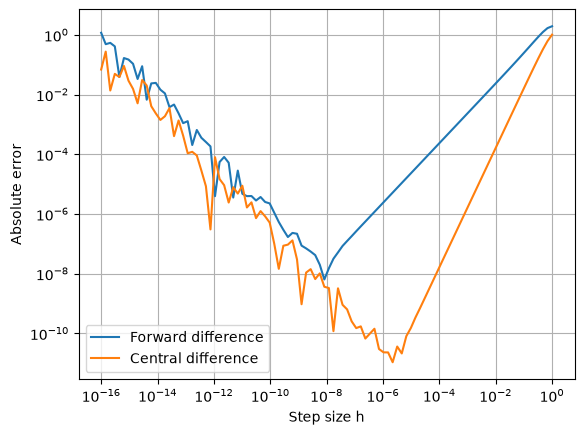

In [156]:
h_values = np.logspace(-16, 0, 100) # Using logspace to create logarithmically spaced step

# Storing the errors
forward_errors = np.array([]) 
central_errors = np.array([])

# Getting the analytical value
analytical = damped_velocity(0.8)

for h in h_values:

  forward_diff_approx = derivative_at(damped_angle, 0.8, h, forward_diff)
  forward_errors = np.append(forward_errors, abs(forward_diff_approx - analytical))

  central_diff_approx = derivative_at(damped_angle, 0.8, h, central_diff)
  central_errors = np.append(central_errors, abs(central_diff_approx - analytical))

# Using loglog to plot the errors on a logarithmic scale for both axes
plt.loglog(h_values, forward_errors, label="Forward difference")
plt.loglog(h_values, central_errors, label="Central difference")

plt.xlabel("Step size h")
plt.ylabel("Absolute error")
plt.legend()
plt.grid()
plt.show()


In [157]:
best_forward_index = np.argmin(forward_errors)
best_central_index = np.argmin(central_errors)

print("Best forward h:", h_values[best_forward_index])
print("Minimum forward error:", forward_errors[best_forward_index])

print("Best central h:", h_values[best_central_index])
print("Minimum central error:", central_errors[best_central_index])

Best forward h: 8.302175681319769e-09
Minimum forward error: 6.3908038860915894e-09
Best central h: 2.2051307399030503e-06
Minimum central error: 1.0740297540223764e-11


Using `argmin` I get the minimum value of each error array. 

For forward approximation the best step h is: 8.302175681319769e-09 with error of 6.3908038860915894e-09.

For central approximation the best step h is: 2.2051307399030503e-06 with error of 1.0740297540223764e-11.

### 3.5 Conclusion

The truncation-error region where h is large happens because the finite-difference formulara are approximated using a large interval,
which gives bigger errors. 

The round-of-error in where the h is small, happens because the differnce between the points calculated are extremly small. Computers store numbers with limited precision, so subcration introuces round of error and increases as h is decresing.

The central diffrence uses points on both sides, while forward difference uses only point on one side. This makes the central difference more accurate. 

## 4. Automatic for the people?

### 4.1 A small class first

In this section, methods are added to the Point class to illustrate how object-oriented programming encapsulates state and behavior


In [ ]:
class Point:
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def distance_from_origin(self):
        return np.sqrt(self.x**2 + self.y**2)
    
    def move(self, dx, dy):
        self.x += dx
        self.y += dy

    def location (self):
        return self.x, self.y
        
        

point1 = Point(3, 4)
point2 = Point(6, 8)

print(point1.distance_from_origin())
print(point2.distance_from_origin())

print(point1.location())
point1.move(-3, 1)
print(point1.location())

The python class `point` keeps data of the point itself. Methods are used to change, or sometimes view the data. Such methods could be `distance_from_origin`, and `move_point`.

### 4.2 A specialized application: automatic differentiation

In [ ]:
class Dual:
    """Store a function value and its derivative."""
    def __init__(self, value, derivative=0.0):
        self.value = value
        self.derivative = derivative

    def __repr__(self):
        return f"Dual(value={self.value}, derivative={self.derivative})"

    def __add__(self, other):
        return Dual(self.value + other.value,
                self.derivative + other.derivative)

    def __sub__ (self, other):
        return Dual(self.value - other.value,
                self.derivative - other.derivative)

    def __neg__ (self):
        return Dual(-self.value, -self.derivative)

    def __mul__(self, other):
        value = self.value * other.value

        derivative = (
            self.derivative * other.value
            + self.value * other.derivative
        )

        return Dual(value, derivative)

    def __truediv__(self, other):
        value = self.value / other.value

        derivative = (
            self.derivative * other.value
            - self.value * other.derivative
        ) / (other.value**2)

        return Dual(value, derivative)
    


x = Dual(3,1)
c = Dual(3)

print(x)
print(c)

The derivatives of `x` and `c` differ because `x` represents the variable $x$, whose derivative with respect to itself is 1. `c` represents a constant, whose derivative is 0. Since the default value of the `derivative` parameter in the `Dual` class is `0.0`, `Dual(3)` gets derivative 0.

Each `Dual` object encapsulates a function value and its derivative. These are stored as `value` and `derivative`.

### 4.3 Addition and subtraction


In [ ]:
u = Dual(1, 2)
v = Dual(3, 4)
print(u + v)
print(u - v)
print(-u)

### 4.4 Multiplication and division

To make the `Dual` class work with multiplication and division, I implemented `__mul__` and `__truediv__`.

For multiplication, the product rule is used:

$$
(fg)' = f'g + fg'
$$

For division, the quotient rule is used:

$$
\left(\frac{f}{g}\right)' =
\frac{f'g - fg'}{g^2}
$$

In [ ]:
x = 1.2

One = Dual(1.0)
X = Dual(x, 1)

print(X * X * X)
print(One / (One + X))

`X * X * X` represents:

$$
x^3
$$

For $x=1.2$, the value is:

$$
1.2^3 = 1.728
$$

and the analytical derivative is:

$$
3x^2 = 4.32
$$

The result from the `Dual` class should therefore give approximately a value of `1.728` and a derivative of `4.32`.

`One / (One + X)` represents:

$$
\frac{1}{1+x}
$$

and its analytical derivative is:

$$
-\frac{1}{(1+x)^2}
$$

For `One / (One + X)`, the expression is

$$
\frac{1}{1+x}
$$

At \(x = 1.2\), the value is

$$
\frac{1}{1+1.2} = \frac{1}{2.2} \approx 0.4545.
$$

The analytical derivative is

$$
-\frac{1}{(1+x)^2}
$$

so at \(x = 1.2\),

$$
-\frac{1}{(2.2)^2} \approx -0.2066.
$$

This matches the output from the `Dual` class:
`Dual(value=0.454545..., derivative=-0.206611...)`.

These tests show that multiplication and division of `Dual` objects also calculate the derivative correctly.

### 4.5 Elementary functions


To use the damped oscillation with the `Dual` class, we also need functions such as exponential and cosine.

For these functions, the chain rule is used:

$$
f(g(x))' = f'(g(x)) \cdot g'(x)
$$

The exponential function is given in the assignment. For cosine, the derivative of $\cos(x)$ is $-\sin(x)$, so the chain rule is used to calculate the derivative.

Both functions are tested using `Dual(0.4, 1)`.

In [ ]:
def dual_exp(d):
    value = np.exp(d.value)
    return Dual(value, value * d.derivative)


def dual_cos(d):
    value = np.cos(d.value)
    derivative = -np.sin(d.value) * d.derivative
    return Dual(value, derivative)


d = Dual(0.4, 1)

print(dual_exp(d))
print(dual_cos(d))

For `dual_exp(d)`, the value is $e^{0.4}$ and the derivative is also $e^{0.4}$.

For `dual_cos(d)`, the value is $\cos(0.4)$ and the derivative is $-\sin(0.4)$.

The results show that the chain rule is applied correctly for both functions.

### 4.6 Automatic differentiation of the damped oscillation

The `Dual` class can now be used to evaluate the damped oscillation from Exercise 3.

The time is set to $t=0.8$. The variable `T` is given derivative 1 because it represents the variable with respect to which we differentiate.

The parameters $A$, $\gamma$, and $\omega_0$ are constants, so their derivatives are 0.

The automatic result is then compared with the analytical functions `damped_angle()` and `damped_velocity()`.

In [ ]:
t = 0.8

T = Dual(t, 1)
A = Dual(0.6)
Gamma = Dual(0.05)
Omega0 = Dual(np.pi)

theta_dual = A * dual_exp(-Gamma * T) * dual_cos(Omega0 * T)

print(theta_dual)

print(theta_dual.value, damped_angle(t))
print(theta_dual.derivative, damped_velocity(t))

In [ ]:
for t in [0.4, 1.2]:
    T = Dual(t, 1)

    theta_dual = A * dual_exp(-Gamma * T) * dual_cos(Omega0 * T)

    print("t =", t)
    print("Automatic value:", theta_dual.value)
    print("Analytical value:", damped_angle(t))
    print("Automatic derivative:", theta_dual.derivative)
    print("Analytical derivative:", damped_velocity(t))
    print()

In [ ]:
t = 0.8
h = 1e-2

T = Dual(t, 1)

theta_dual = (
    A
    * dual_exp(-Gamma * T)
    * dual_cos(Omega0 * T)
)

automatic = theta_dual.derivative

forward = derivative_at(
    damped_angle,
    t,
    h,
    forward_diff
)

central = derivative_at(
    damped_angle,
    t,
    h,
    central_diff
)

print("Automatic derivative:", automatic)
print("Forward difference:", forward)
print("Central difference:", central)
print("Analytical derivative:", damped_velocity(t))

The automatic value agrees with `damped_angle(t)`, and the automatic derivative agrees with `damped_velocity(t)`.

The forward and central difference methods only approximate the derivative numerically, while the `Dual` class carries the derivative through the calculation automatically.

The central difference is usually closer to the analytical derivative than the forward difference for the same step size.

### 4.7 Encapsulation and code reusability

The `Point` class encapsulates the coordinates `x` and `y`, together with methods that use or change those coordinates, such as moving the point or finding its distance from the origin. The `Dual` class encapsulates a value and its derivative, and the same differentiation rules are reused whenever different `Dual` objects are combined. This avoids having to write the same logic again for every calculation. Classes are useful in general because they keep related data and functions together and make code easier to reuse and organize, even if automatic differentiation and operator overloading are more specialized uses of classes.

## 5. Derivatives in your pocket

In this exercise, we apply our numerical tools to real sensor data measured using the **phyphox** application on a smartphone. Our goal is to verify that we can start with a measured angular velocity $\omega(t)$, integrate it to compute the angle $\theta(t)$, and then differentiating $\theta(t)$ to get the original angular velocity:

$$
\omega'(t)
\approx
\omega(t)
$$


### 5.1 Loading and plotting gyroscope data

We import the data from a CSV file using the `pandas` library. The recorded file contains timestamps along with three spatial rotation axes (x, y and z):

Columns in file: ['Time (s)', 'Gyroscope x (rad/s)', 'Gyroscope y (rad/s)', 'Gyroscope z (rad/s)', 'Absolute (rad/s)']


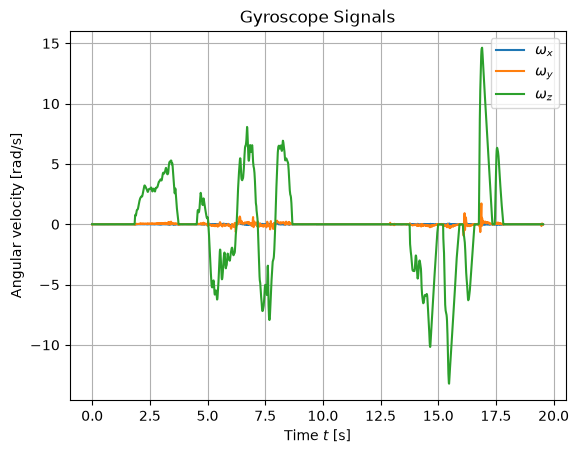

In [158]:
# Loads the csv file
df = pd.read_csv('gyroscope.csv')

# Prints columns to see what data we have available
print("Columns in file:", df.columns.tolist())

# Saving data to variables using pandas iloc (which returns row then col)
t = df.iloc[:, 0].values # all rows and first column (time)
wx = df.iloc[:, 1].values # col 2: x
wy = df.iloc[:, 2].values # col 3: y
wz = df.iloc[:, 3].values # col 4: z

# Plotting all rotation axes in the same graph:
plt.plot(t, wx, label=r'$\omega_x$')
plt.plot(t, wy, label=r'$\omega_y$')
plt.plot(t, wz, label=r'$\omega_z$')
plt.xlabel('Time $t$ [s]')
plt.ylabel('Angular velocity [rad/s]')
plt.title('Gyroscope Signals')
plt.legend()
plt.grid()
plt.show()


From the above signals, the y-axis channel ($\omega_{y}$) gives the most prominent signal amplitude. Therefore, we select this channel for our variable omega ($\omega$) to do computations on.

### 5.2 Integrating angular velocity

Using the composite trapezoidal rule implementation given, we integrate the angular velocity $\omega$ over time to get the angular position $\theta(t)$:

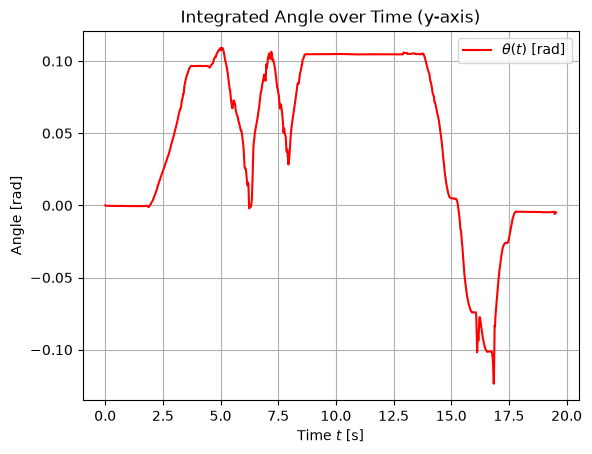

In [159]:
def cumulative_trapezoid(y, t, initial=0.0):
    """Return the cumulative integral of y with the same length as y."""
    areas = 0.5 * (y[1:] + y[:-1]) * np.diff(t)
    return initial + np.concatenate(([0.0], np.cumsum(areas)))

# We select the y-axis as the omega to compute the integral on:
omega = wy
theta = cumulative_trapezoid(omega, t)

# Plotting the angle theta(t):
plt.plot(t, theta, color='red', label=r'$\theta(t)$ [rad]')
plt.xlabel('Time $t$ [s]')
plt.ylabel('Angle [rad]')
plt.title('Integrated Angle over Time (y-axis)')
plt.grid()
plt.legend()
plt.show()


Setting `initial = 0.0` assumes a starting reference angle of 0 radians. Any non-zero position only shifts the entire resulting angle curve vertically, without changing its shape.

### 5.3 Recovering angular velocity

To recover an estimate of the original angular velocity, we use numerical differentiation. Here we can re-use the functions `forward_diff()` and `central_diff()` from Exercise 3 directly into the array `theta`.

Since numerical differentiation requires a sampling spacing parameter, we determine average time step $h$ from timestamps:

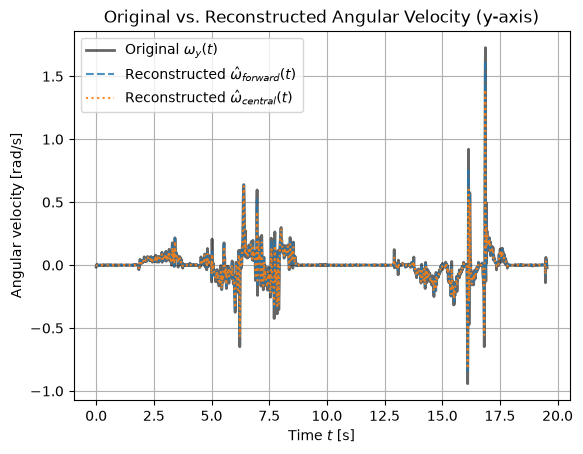

In [160]:
# Step size: average spacing between two consecutive time points
h = np.mean(np.diff(t))

# We use the already defined functions from ex 3:
omega_forward = forward_diff(theta, h)
omega_central = central_diff(theta, h)

# Due to shorter arrays we have to align the time vectors:
t_forward = t[:-1]   # len(t) - 1
t_central = t[1:-1]  # len(t) - 2

# Overlay comparison plot
plt.plot(t, omega, label=r'Original $\omega_y(t)$', color='black', alpha=0.6, linewidth=2)
plt.plot(t_forward, omega_forward, '--', label=r'Reconstructed $\hat{\omega}_{forward}(t)$', alpha=0.8)
plt.plot(t_central, omega_central, ':', label=r'Reconstructed $\hat{\omega}_{central}(t)$', alpha=0.9)
plt.xlabel('Time $t$ [s]')
plt.ylabel('Angular velocity [rad/s]')
plt.title('Original vs. Reconstructed Angular Velocity (y-axis)')
plt.legend()
plt.grid()
plt.show()


### 5.4 Analysis

Differentiating integrated angle array $\theta(t)$ successfully recovers the original gyroscope signal $\omega_{y}(t)$ with minimal error. Both numerical methods match the peaks and zero-crossings of the original data. This shows that numerical integration and differentiation work as inverse operations on datasets from real experiments.

In the plot, prominent positive peaks represent rapid rotations in one direction around the phone's y-axis, while the negative minimums show returning counter-rotations back toward the initial position.

### Reflection: Jone B

From these exercises I learned more about how numerical differentiation works and how the choice of step size can affect the accuracy of the result. I also learned the difference between forward and central difference, and why very small values of $h$ can actually make the result worse because of round-off error. Exercise 4 helped me understand classes better, especially how data and methods can be stored together in the same object. I also got a better understanding of automatic differentiation and how a `Dual` object can keep track of both a value and its derivative while calculations are being performed. Overall, I feel more comfortable with both numerical methods and using classes in Python.

### Reflection: Petter

In this project, I have learned about floating-point arithmetic, NumPy vectorization and analysing self-measured data.

From the first exercise, I learned how floating-point arithmetic works in Python and how computer memory limits affect numerical calculations. Inspecting `sys.float_info` showed me why expressions like `0.1 + 0.2` do not equal `0.3` exactly in binary. This proves why we need to use comparisons such as `(abs(a - b) < precision)` instead of `==` when comparing decimal values.

Working with NumPy showed the advantages of vectorization over regular Python loops. Using functions like `np.logical_and` and `np.where`, I learned how to combine conditions and filter data downstream without needing to modify code further up.

Lastly, processing data from phyphox was a good practical test of earlier declared functions. Integrating the angular velocity to then differentiate the position angle matched the raw signal closely, proving that even on real experimental data, integration and differentiation work as inverse operations.
